# Dynamikk i forsyningskjeder

## En gammel kjenning

Husk at $A = D - C$ var matrisa med produksjonsratene? Den basic ligning blir:

$$
\frac{d\vec{q}}{dt} = A\vec{u},
$$

Hvor $\vec{q}$ er en vektor med lagerføring av forskjellige varer, og $\vec{u}$ er en vektor med produksjonsrater. For å gjør livet mer komplisert, er det generelt slik at vi justerer $\vec{u}(\vec{q})$ avhengig av lagerføringen.

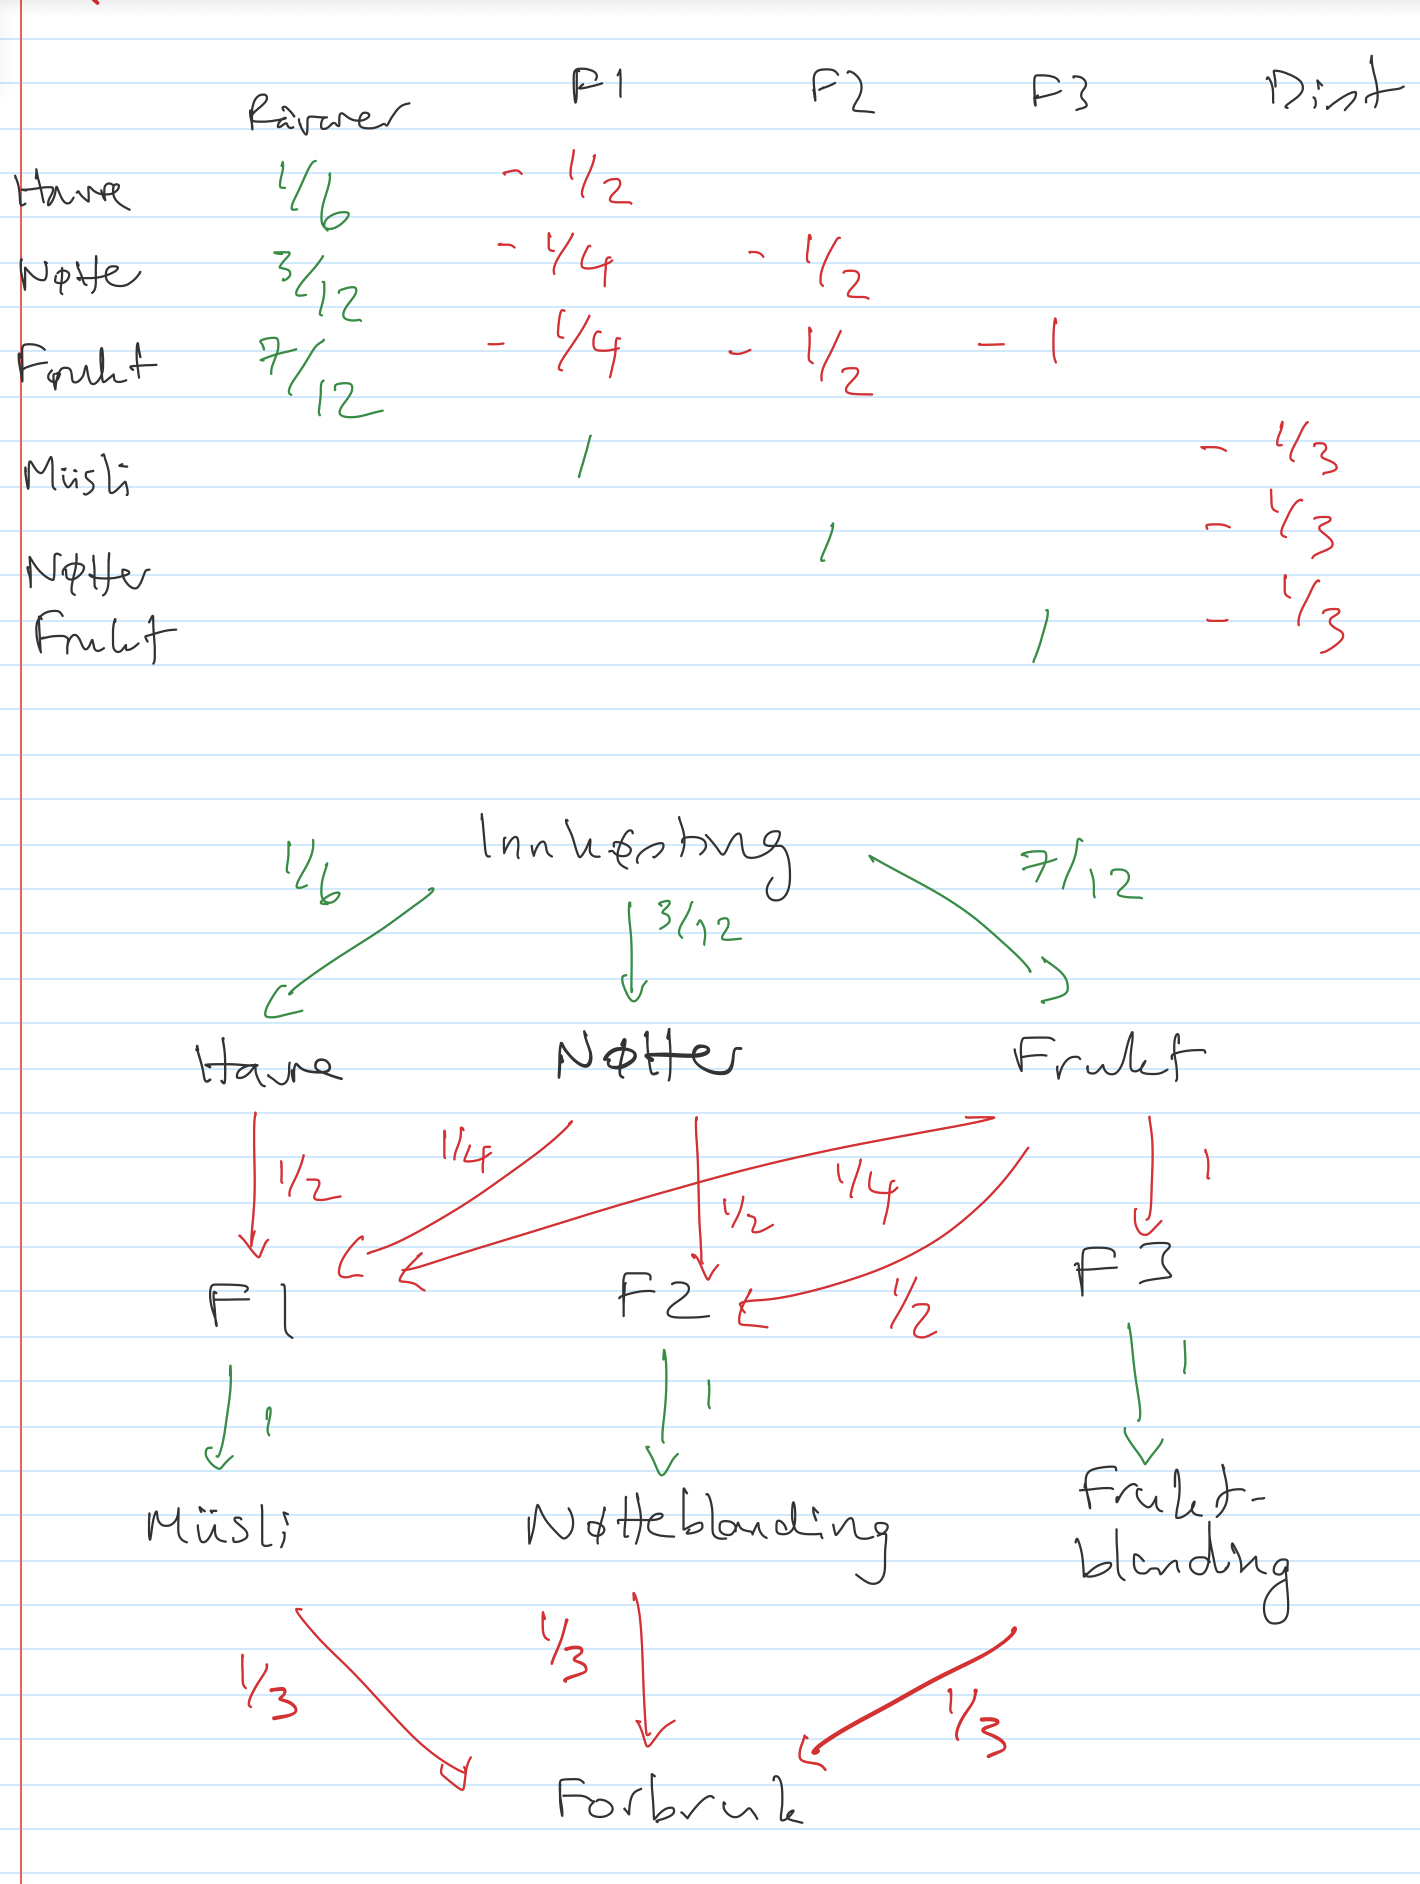

In [1]:
import numpy as np

# Relativ innhøsting av havre, nøtter og rosiner
prod = np.array([1/6,3/12,7/12])

# Forbruk av fabrikk 1 i produksjon av muslibarer (altså en muslibar er 50% havre, 25% nøtter og 25% rosiner)
fab1 = np.array([1/2, 1/4, 1/4])

# Forbruk av fabrikk 2 ... nøtteblandinger (en nøtteblanding er 50% nøtter og 50% rosiner)
fab2 = np.array([0, 1/2, 1/2])

# Forbruk av fabrikk 3 - tørket frukt er 100% rosiner
fab3 = np.array([0, 0, 1])

# Etterspørsel av varer - det selges like mye av hvert produkt, altså 33% av salg er muslibarer osv
forbruk = np.array([1/3, 1/3, 1/3])

D = np.zeros([5,6])
C = np.zeros([5,6])

# Leveransematrisa
D[0,0:3]=prod
D[1,3]=1
D[2,4]=1
D[3,5]=1

# Forbruksmatrisa
C[1,0:3]=fab1
C[2,0:3]=fab2
C[3,0:3]=fab3
C[4,3:6]=forbruk

# Forsyningskjedematrise
A = np.transpose(D-C)
print(A)

[[ 0.16666667 -0.5         0.          0.          0.        ]
 [ 0.25       -0.25       -0.5         0.          0.        ]
 [ 0.58333333 -0.25       -0.5        -1.          0.        ]
 [ 0.          1.          0.          0.         -0.33333333]
 [ 0.          0.          1.          0.         -0.33333333]
 [ 0.          0.          0.          1.         -0.33333333]]


## Produksjonsstrategi

Vi må velge enn passende produksjonsstrategi $\vec{u}=\vec{u}(\vec{q})$. Husk at $\vec{q}$ er lagerføring av (havre, nøtter, frukt, musli, nøttebladning, fruktblanding), mens $\vec{u}$ er (innhøsting, produksjon musli, produksjon nøtteblanding, produksjon fruktblanding, forbruk). 

Det er innebakt i modellen at forbruk av alle varer er like, eller at relativ etterspørsel av de forskjellige varer er lik. Ellers kunne vi latt matrisa $A$ endre med tid, men det skal vi ikke tenke på her.

Etterspørsel har vi ingen kontroll over, så la oss anta at $u_5 = D$, for øyeblikket konstant i tid.

Ellers, la oss anta at vi har en ideell lagerføring $\vec{q}_D$. Det nærmest vi kommer strategien fra forrige oppgaven er å forsøke å ta inn forskjell mellom nåværende og ideell lagerføring i tid $T$, dvs vi vil ha

$$
\frac{d\vec{q}}{dt} = A\vec{u} = \frac{\vec{q}_D - \vec{q(t - T_G)})}{T}
$$

Hvor vi har lagt inn en forsinkelse $T_G$ i bestilling, som før. Hva slags produksjon $\vec{u}$ er det? Vi ønsker å løse

$$
A\vec{u}(t) = \frac{\vec{q}_D - \vec{q(t - T_G)})}{T}
$$

for $\vec{u}$, hvor i tillegg $u_5 = D$ (det kan vi få med å legge en ekstra rad til $A$). Det er et lineært system, men den har trolig ingen løsninger - mest sannsynlig er det ingen perfekt måte å endre bestillingene på. Men vi kan velge en såkalt minst kvadraters løsning, altså produksjon $\vec{u}$ slik at forskjell mellom venstre og høyre sider blir så lite som mulig.

Resultatet blir en ligning som vi kan løse med koden under.

In [6]:
def forsinkede_vektor(A, D, T, TG, q0, qd, a, b, N):
    AL = np.vstack((A, np.array([0,0,0,0,1])))
    t = np.linspace(a,b,N)
    h = (b-a)/(N-1)
    q = np.zeros((6, N))
    q[:,0] = q0
    u = np.zeros((5, N))
    j = int(TG/h)
    for i in np.arange(N):
        if i<j:
            b = (qd - q[:,i])/T
        else:
            b = (qd-q[:,i-j])/T
        u[:,i] = np.linalg.lstsq(AL, np.append(b,D), rcond=None)[0]
        if i<(N-1):
            q[:,i+1] = q[:,i] + h*(A @ u[:,i])
    return q, u, t

q0 = np.array([40, 30, 25, 20, 20, 20])
qd = np.array([20,20,20,10,10,10,])

q, u, t = forsinkede_vektor(A, 1, 5, 10, q0, qd, 0, 100, 100)

## Plotter med lagerføring over tid

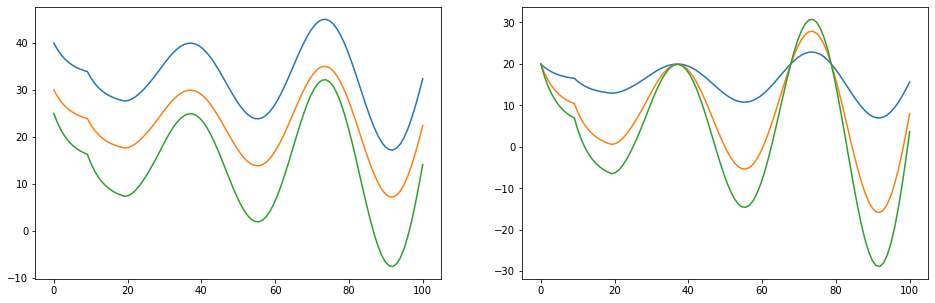

In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,5))

ax1.plot(t, q[0,:])
ax1.plot(t, q[1,:])
ax1.plot(t, q[2,:])

ax2.plot(t, q[3,:])
ax2.plot(t, q[4,:])
ax2.plot(t, q[5,:])

## Plotter med produksjonsrater over tid

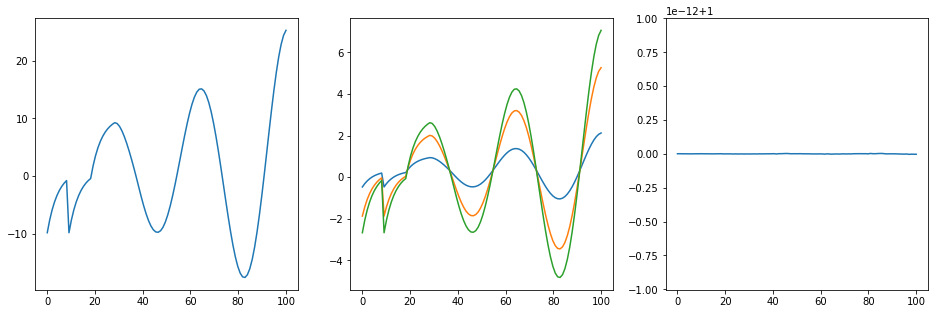

In [11]:
fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,5))

ax1.plot(t, u[0,:])

ax2.plot(t, u[1,:])
ax2.plot(t, u[2,:])
ax2.plot(t, u[3,:])

ax3.plot(t, u[4,:])

## Oppgaver

1. Kjør koden og følg utviklingen over tid
2. Hva finner du? Merker du en bullwhip effekt her også?


## Likevekt

Husk tilbake til da vi så på likevekt, $A\vec{u} = 0$. Vi fant den ved hjelp av SVD (singularverdi-dekomposisjon):

$$
A = U\Sigma V.
$$

Hadde $A$ vært kvadratisk (altså med rader og kolonner av samme størrelse) kunne vi ha sagt at $\vec{u}$ var en egenvektor med egenverdi null. Men det gir ikke mening for en $6\times 5$ matrise, slik vi har her. SVD er nært relatert til egendekomposisjon av $AA'$ og $A'A$, som er begge kvadratiske, men vi trenger ikke detaljene her.

I denne modellen er $\vec{u}$ bestemt ut fra forskjell mellom nåværende og ønsket lagerføring. Det er naturlig å anta at om vi begynner med ønsket lagerføring allerede på plass, så klarer vi å velge $\vec{u}$ til å være en likevektstilstand (om den eksisterer), slik at vi beholder vårt ønsket lagerføring.

## Oppgaver

1. Hva skjer hvis vi velger $q_0$ lik $q_D$. Kjør koden igjen. Får vi likevekt? Blir $\vec{u}$ som du beregnet i uke 1?
2. Prøv med $q_0$ bare kort avstand fra $q_D$. Konvergerer vi mot likevekt?
3. Hva skjer hvis vi velger $q_0 = q_D$, men forandrer matrisa $A$ til en variant fra øving 1 som ikke har noen likevekt?

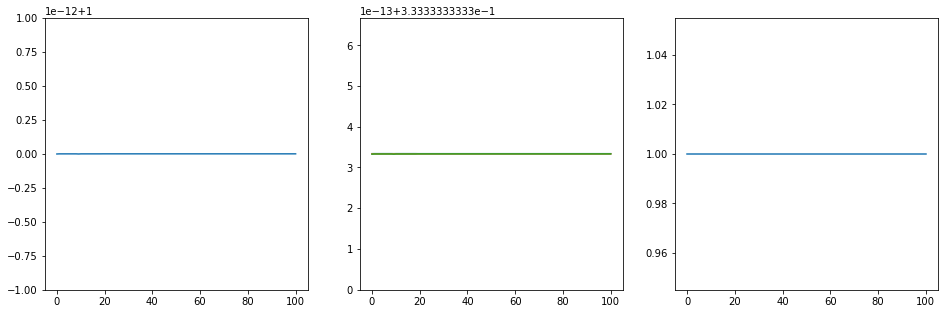

In [13]:
q0 = np.array([20,20,20,10,10,10])
qd = np.array([20,20,20,10,10,10])

q, u, t = forsinkede_vektor(A, 1, 5, 10, q0, qd, 0, 100, 100)

fig2, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16,5))

ax1.plot(t, u[0,:])

ax2.plot(t, u[1,:])
ax2.plot(t, u[2,:])
ax2.plot(t, u[3,:])

ax3.plot(t, u[4,:])